# Netflix Content Analytics


## Proyect Overview

This project explores the Netflix Movies and TV Shows dataset to identify trends in content production, distribution, genres, and ratings. Using Python and exploratory data analysis techniques, the project transforms raw data into meaningful insights through data cleaning, visualization, and KPI generation.

### Technologies

- Python
- Pandas
- NumPy
- Matplotlib

## Business Understanding

Streaming platforms rely on data to understand the composition of their content catalog and identify trends that support strategic decisions.

The objective of this analysis is to answer questions such as:

- Which countries produce the most Netflix content?
- How has the catalog evolved over time?
- What genres dominate the platform?
- What is the distribution between Movies and TV Shows?
- Which content ratings are the most common?

## Dataset Description

The dataset contains information about movies and TV shows available on Netflix, including:

- Title
- Type (Movie or TV Show)
- Director
- Cast
- Country
- Release Year
- Rating
- Duration
- Genres
- Date Added

The dataset is used to explore content trends, geographical distribution, genres, and catalog evolution over time.

## Data Loading

In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data loading
df = pd.read_csv("data/NetFlix.csv")

## Initial inspection

Before performing any analysis, the dataset is inspected to understand its structure, identify missing values, and verify data types.

In [ ]:
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...
5,s1002,Movie,Blue Ruin,Jeremy Saulnier,"Macon Blair, Devin Ratray, Amy Hargreaves, Kev...","United States, France",25-Feb-19,2013,R,90,"Independent Movies, Thrillers",Bad news from the past unhinges vagabond Dwigh...
6,s1003,Movie,Blue Streak,Les Mayfield,"Martin Lawrence, Luke Wilson, Peter Greene, Da...","Germany, United States",1-Jan-21,1999,PG-13,94,"Action & Adventure, Comedies",A jewel thief returns to his hiding place afte...
7,s1004,Movie,Blue Valentine,Derek Cianfrance,"Ryan Gosling, Michelle Williams, Faith Wladyka...",United States,5-Jul-18,2010,R,112,"Dramas, Independent Movies, Romantic Movies",As Cindy and Dean muddle through their languis...
8,s1005,Movie,BluffMaster!,Rohan Sippy,"Abhishek Bachchan, Priyanka Chopra, Riteish De...",India,8-Jan-21,2005,TV-14,129,"Comedies, International Movies, Romantic Movies",When his girlfriend learns the truth about his...
9,s1006,Movie,Blurred Lines: Inside the Art World,Barry Avrich,NaN,Canada,31-Dec-17,2017,TV-MA,85,Documentaries,Artists and industry insiders shed light on th...


Dataset dimensions

In [ ]:
df.shape

(7787, 12)

## Business Question 1

**Which countries contribute the largest amount of content to Netflix's catalog?**

Understanding the geographical distribution of content helps identify the markets that contribute the most to Netflix's library and reveals regional trends in content production.

 Data Cleaning

In [ ]:
df['type'].isna().sum()

np.int64(0)

In [ ]:
df['country'].isna().sum()

np.int64(507)

In [ ]:
df['country'] = df['country'].str.split(',')

In [ ]:
# Count titles by country
country_distribution = (
    df
    .explode("country")
    .groupby("country")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

Key metrics

In [ ]:
print(f"Total titles = {country_distribution.sum()}")

Total titles = 6037


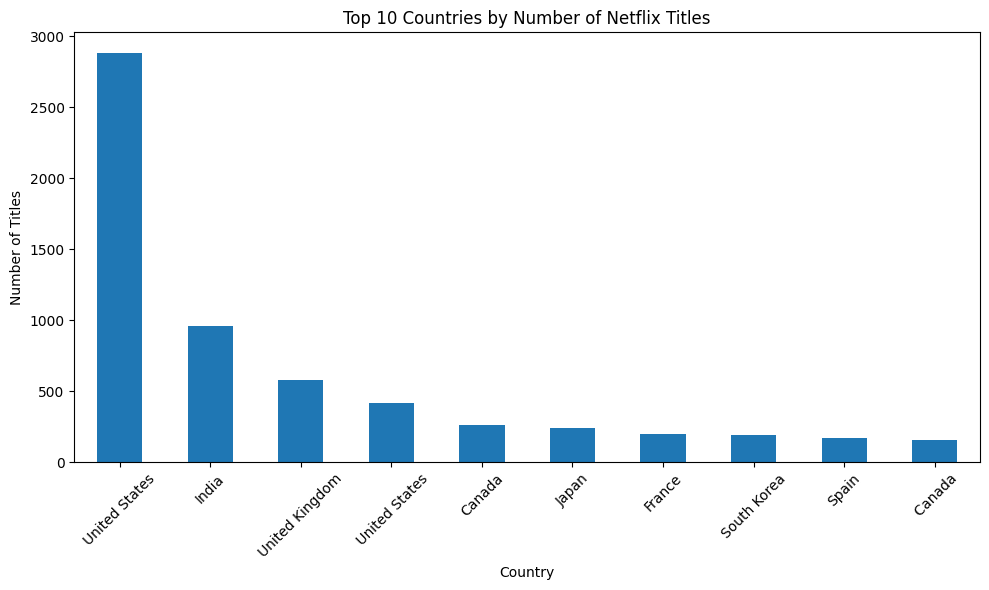

In [ ]:
plt.figure(figsize=(10,6))

country_distribution.plot(kind="bar")

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.savefig("countries.png", dpi=300, bbox_inches="tight")

plt.tight_layout()

plt.show()

### Business Insight

The United States dominates Netflix's catalog, followed by India and the United Kingdom.

This suggests that Netflix relies heavily on content produced in these countries, reflecting both production capacity and market demand.

The remaining countries contribute significantly fewer titles, indicating a highly concentrated content distribution.

## Business Question 2

**How has Netflix's content catalog evolved over time?**

Analyzing the release year of titles helps identify production trends and understand how Netflix's catalog has expanded over the years.

This analysis provides insights into the growth of content production and highlights periods of significant expansion.

In [ ]:
# Data cleaning
df['release_year'].isna().sum()

np.int64(0)

Key metrics

In [ ]:
print(f"Years analyzed: {df['release_year'].min()} - {df['release_year'].max()}")
print(f"Total titles: {len(df):,}")

Years analyzed: 1925 - 2021
Total titles: 7,787


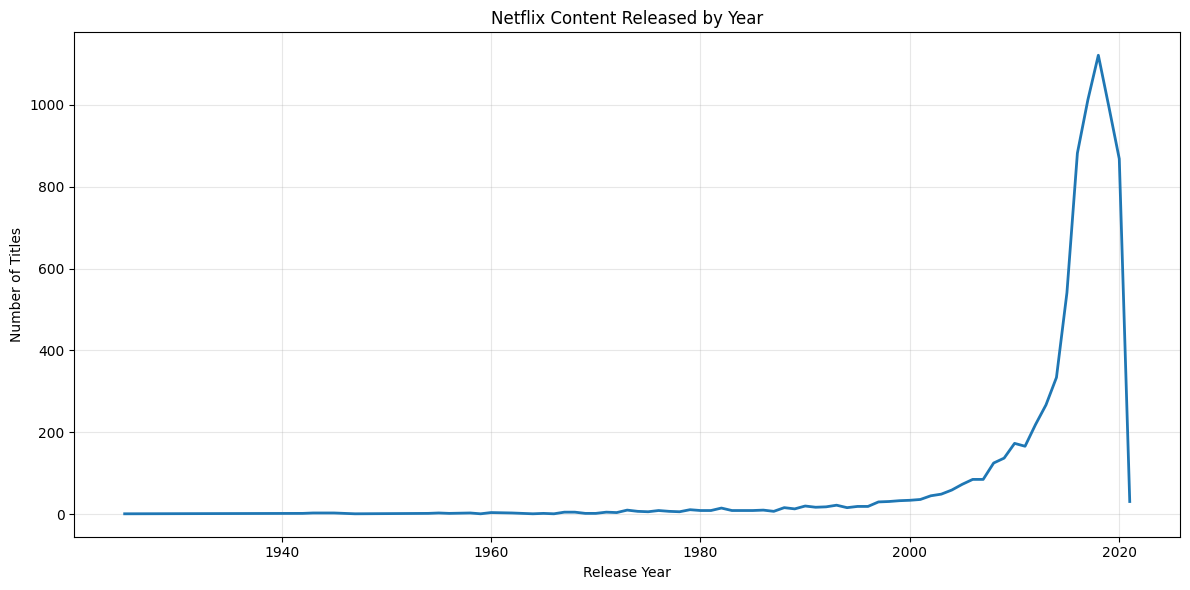

In [ ]:
# Count titles released each year
titles_per_year = (
    df.groupby("release_year")
      .size()
)

plt.figure(figsize=(12,6))

plt.plot(
    titles_per_year.index,
    titles_per_year.values,
    linewidth=2
)

plt.title("Netflix Content Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.grid(alpha=0.3)

plt.savefig("release_year.png", dpi=300, bbox_inches="tight")

plt.tight_layout()

plt.show()

### Business Insight

The analysis shows a sustained increase in content production over the years, with a particularly rapid growth beginning in the 2000s and accelerating after 2015.

This trend reflects the global expansion of the streaming industry and Netflix's increasing investment in both original productions and licensed content.

The concentration of titles in recent years indicates a strategic effort to continuously expand the platform's catalog and meet the growing demand for digital entertainment.

## Business Question 3

**What is the composition of Netflix's catalog in terms of Movies and TV Shows?**

Understanding the balance between Movies and TV Shows provides insights into Netflix's content strategy and reveals whether the platform prioritizes feature-length productions or episodic content.

Key metrics

In [ ]:
# Key metrics
content_distribution = df["type"].value_counts()

print(f"Movies: {content_distribution['Movie']:,}")
print(f"TV Shows: {content_distribution['TV Show']:,}")

movie_percentage = (
    content_distribution["Movie"] /
    content_distribution.sum()
) * 100

tv_percentage = (
    content_distribution["TV Show"] /
    content_distribution.sum()
) * 100

print(f"Movies: {movie_percentage:.1f}%")
print(f"TV Shows: {tv_percentage:.1f}%")

Movies: 5,377
TV Shows: 2,410
Movies: 69.1%
TV Shows: 30.9%


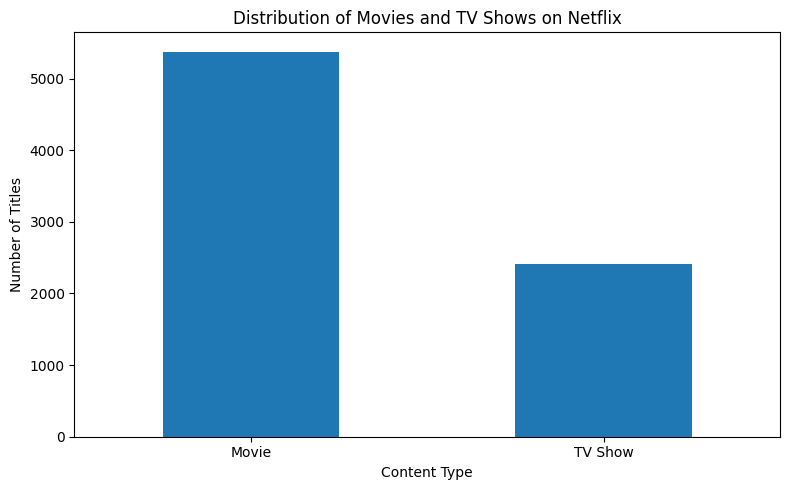

In [ ]:
plt.figure(figsize=(8,5))

content_distribution.plot(kind="bar")

plt.title("Distribution of Movies and TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.xticks(rotation=0)

plt.savefig("content_distribution.png", dpi=300, bbox_inches="tight")

plt.tight_layout()

plt.show()

### Business Insight

Movies represent the majority of Netflix's catalog, while TV Shows account for a smaller but significant portion of the available content.

This distribution suggests that Netflix has historically focused on expanding its movie library while steadily increasing investment in serialized content to meet evolving audience preferences.

## Business Question 4

**When are TV Shows most frequently added to Netflix?**

Identifying the months with the highest number of TV Show releases helps reveal seasonal publishing patterns and provides insights into Netflix's content release strategy.

Understanding these trends can support planning decisions for future content launches and marketing campaigns.

To answer this question, only TV Shows are considered. The analysis is based on the month in which each title was added to Netflix, allowing us to identify periods with the highest concentration of releases.

Key metrics

In [ ]:
# Convertimos el date_addes en formato de fecha y extraemos el mes
df['monthly_release'] = pd.to_datetime(df['date_added']).dt.month

# Agrupamos los TV Shows por mes
grouped_data = df[df['type'] == 'TV Show'].groupby('monthly_release')['type'].count().reset_index()

grouped_data.rename(columns={'type': 'TV Show Count'}, inplace=True)


table = grouped_data.pivot_table(index='monthly_release', values='TV Show Count')
print(table)


                 TV Show Count
monthly_release               
1.0                      197.0
2.0                      144.0
3.0                      198.0
4.0                      181.0
5.0                      172.0
6.0                      165.0
7.0                      197.0
8.0                      204.0
9.0                      204.0
10.0                     232.0
11.0                     227.0
12.0                     279.0


/tmp/ipykernel_693/1205018183.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['monthly_release'] = pd.to_datetime(df['date_added']).dt.month


Data preparation

In [ ]:
# Count TV Shows released each month
monthly_release = (
    df[df['type'] == 'TV Show']
    .groupby('monthly_release')
    .size()
    .sort_index()
)

Key metrics

In [ ]:
# Key Metrics

peak_month = monthly_release.idxmax()
peak_releases = monthly_release.max()

months = {
    1:"January",
    2:"February",
    3:"March",
    4:"April",
    5:"May",
    6:"June",
    7:"July",
    8:"August",
    9:"September",
    10:"October",
    11:"November",
    12:"December"
}

print(f"Peak release month: {months[peak_month]}")
print(f"TV Shows released: {peak_releases}")

Peak release month: December
TV Shows released: 279


Visualization

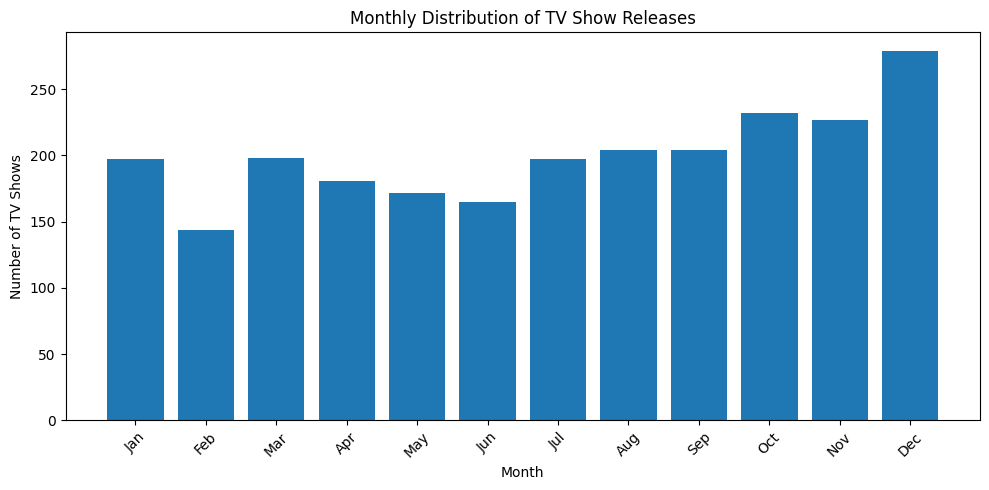

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(monthly_release.index, monthly_release.values)

plt.xticks(
    monthly_release.index,
    ['Jan','Feb','Mar','Apr','May','Jun',
     'Jul','Aug','Sep','Oct','Nov','Dec'],
    rotation=45
)

plt.title("Monthly Distribution of TV Show Releases")
plt.xlabel("Month")
plt.ylabel("Number of TV Shows")

plt.savefig("monthly_tv_releases.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Business Insight

The analysis indicates that **July** and **December** consistently record the highest number of TV Show releases on Netflix. This concentration suggests that the platform strategically schedules a larger portion of its content additions during these months, likely to capitalize on periods of increased viewer activity.

These seasonal patterns provide valuable insights into Netflix's historical release strategy and may serve as a useful reference when planning future content launches or marketing campaigns.

It is important to note that this analysis is based on the date when titles were added to Netflix, rather than their original production or premiere dates.

## Business Question 5

**Which genres dominate Netflix's catalog?**

Understanding the most common genres helps identify the type of content that Netflix offers most frequently and provides insights into the platform's overall content strategy.

This analysis can reveal audience-oriented trends and highlight the genres that receive the greatest representation within the catalog.

To answer this question, the genres listed in the **listed_in** column are separated into individual categories. This allows each genre to be counted independently, providing an accurate representation of their frequency across Netflix's catalog.

In [ ]:
# Prepare data

genre_distribution = (
    df["genres"]
    .str.split(", ")
    .explode()
    .value_counts()
)

top_genres = genre_distribution.head(10)

Key metrics

In [ ]:
print(f"Total unique genres: {genre_distribution.shape[0]}")
print(f"Most common genre: {genre_distribution.idxmax()}")
print(f"Titles in this genre: {genre_distribution.max()}")

Total unique genres: 42
Most common genre: International Movies
Titles in this genre: 2437


Visualization

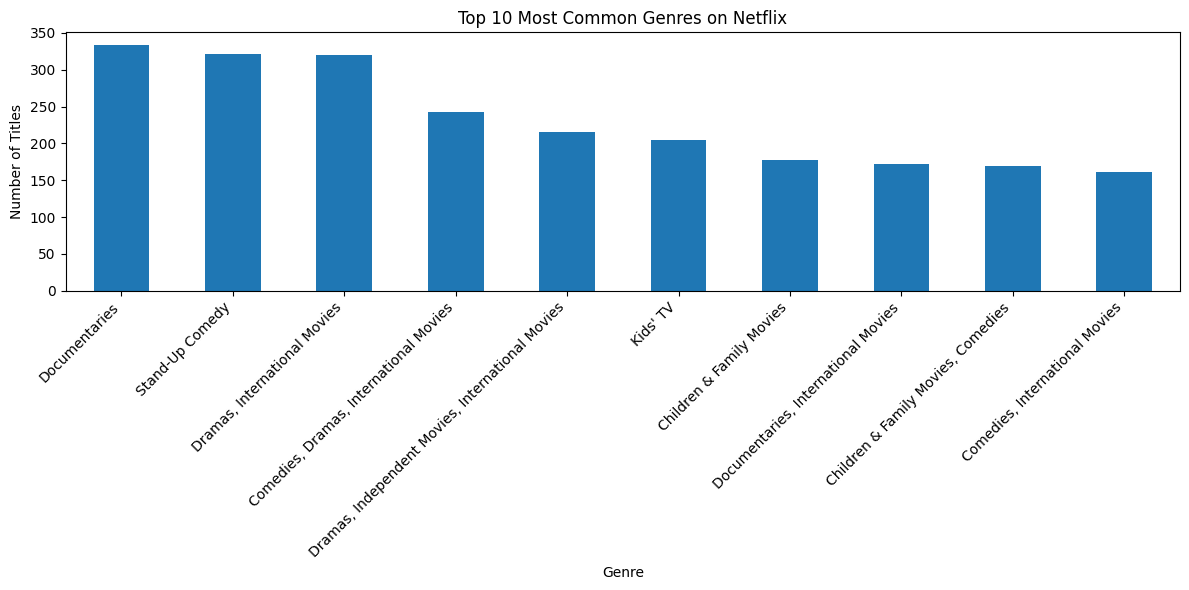

In [ ]:
plt.figure(figsize=(12,6))

top_genres.plot(kind="bar")

plt.title("Top 10 Most Common Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45, ha="right")

plt.savefig("genres.png", dpi=300, bbox_inches="tight")

plt.tight_layout()

plt.show()

### Business Insight

The analysis shows that Netflix's catalog is concentrated around a relatively small number of genres. Rather than distributing content evenly across many categories, the platform appears to prioritize genres with broad audience appeal.

This concentration suggests a strategy focused on maximizing viewer engagement while maintaining a diverse catalog through complementary niche genres. Understanding these distributions can support future decisions regarding content acquisition and production priorities.

# Executive Summary

This exploratory analysis examined Netflix's content catalog to identify production trends, content composition, seasonal release patterns, and genre distribution.

The main findings include:

- The United States remains the largest contributor to Netflix's catalog, followed by several other major content-producing countries.
- Netflix's catalog has experienced significant growth over the past two decades, reflecting the rapid expansion of the streaming industry.
- Movies represent the majority of the platform's available titles, although TV Shows constitute an important and growing segment.
- TV Show releases exhibit seasonal patterns, suggesting a strategic scheduling of content additions throughout the year.
- A relatively small number of genres account for a large proportion of Netflix's catalog, indicating a content strategy focused on broad audience appeal.

Overall, this project demonstrates how exploratory data analysis can transform raw data into actionable business insights through data cleaning, visualization, and statistical exploration.